1.	This exercise involves the Auto data set studied in the lab. Make sure that the missing values have been removed from the data.

In [9]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna()

print(df.head())
print(df.columns)

df = pd.read_csv("D:\\PG(sem3)\\ML\\Assignment\\auto-mpg.csv")

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')


In [5]:
df = df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


(a) Which predictors are quantitative and which are qualitative?

In [10]:
# quantitative = numeric columns
quantitative = df.select_dtypes(include=[np.number]).columns.tolist()

# qualitative = non-numeric columns
qualitative = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Quantitative predictors:")
print(quantitative)

print("\nQualitative predictors:")
print(qualitative)

Quantitative predictors:
['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']

Qualitative predictors:
['horsepower', 'car name']


(b) What is the range of each quantitative predictor? You can answer this using the range() function. 

In [11]:
print("Range of quantitative predictors:\n")

for col in quantitative:
    print(f"{col}: {df[col].min()} to {df[col].max()}")

Range of quantitative predictors:

mpg: 9.0 to 46.6
cylinders: 3 to 8
displacement: 68.0 to 455.0
weight: 1613 to 5140
acceleration: 8.0 to 24.8
model year: 70 to 82
origin: 1 to 3


(c) What is the mean and standard deviation of each quantitative predictor?

In [12]:
print(df[quantitative].agg(['mean', 'std']))

            mpg  cylinders  displacement       weight  acceleration  \
mean  23.514573   5.454774    193.425879  2970.424623     15.568090   
std    7.815984   1.701004    104.269838   846.841774      2.757689   

      model year    origin  
mean   76.010050  1.572864  
std     3.697627  0.802055  


(d) Remove the 10th through 85th observations. Find range, mean, and standard deviation again.

In [13]:
# remove observations 10 to 85
df_subset = df.drop(df.index[9:85])

print("Subset shape:", df_subset.shape)

print("\nRange in subset:\n")
for col in quantitative:
    print(f"{col}: {df_subset[col].min()} to {df_subset[col].max()}")

print("\nMean and standard deviation in subset:\n")
print(df_subset[quantitative].agg(['mean', 'std']))

Subset shape: (322, 9)

Range in subset:

mpg: 11.0 to 46.6
cylinders: 3 to 8
displacement: 68.0 to 455.0
weight: 1649 to 4997
acceleration: 8.5 to 24.8
model year: 70 to 82
origin: 1 to 3

Mean and standard deviation in subset:

            mpg  cylinders  displacement       weight  acceleration  \
mean  24.434161   5.366460    186.937888  2934.276398     15.737888   
std    7.896264   1.652674     99.500352   809.398855      2.689542   

      model year    origin  
mean   77.167702  1.596273  
std     3.118103  0.815572  


(e) Investigate the predictors graphically

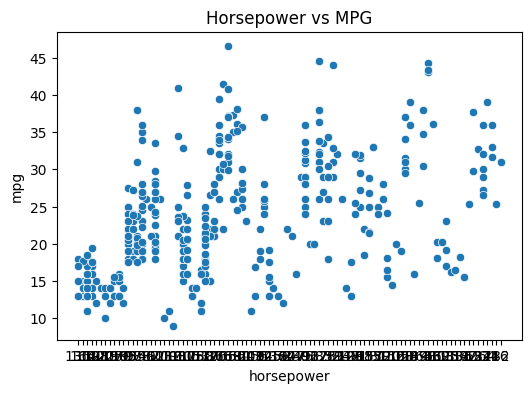

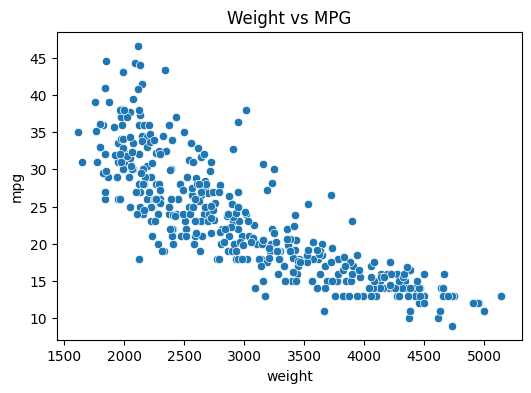

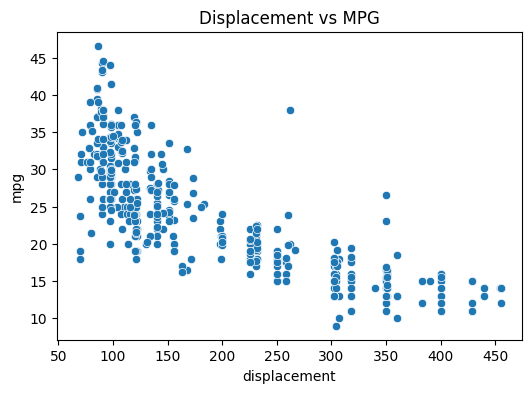

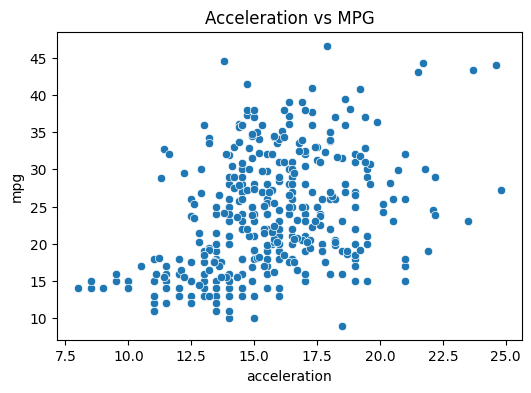

In [15]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="horsepower", y="mpg")
plt.title("Horsepower vs MPG")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="weight", y="mpg")
plt.title("Weight vs MPG")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="displacement", y="mpg")
plt.title("Displacement vs MPG")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="acceleration", y="mpg")
plt.title("Acceleration vs MPG")
plt.show()

(f) Which variables might be useful in predicting mpg?

In [16]:
corr_mpg = df[quantitative].corr(numeric_only=True)["mpg"].sort_values(ascending=False)
print(corr_mpg)

mpg             1.000000
model year      0.579267
origin          0.563450
acceleration    0.420289
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64
